In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

LABEL_NAMES = ["Complete", "Missing P", "Missing I", "Missing O"]


c:\Users\erank\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
import json
from torch.utils.data import Dataset

class EBMNLPDataset(Dataset):
    def __init__(self, json_file, tokenizer, max_length=512):
        with open(json_file, "r", encoding="utf-8") as f:
            self.data = json.load(f)

        self.tokenizer = tokenizer
        self.max_length = max_length

        # Same label mapping as BioBERT experiments
        self.label_map = {
            "Complete": 0,
            "Missing P": 1,
            "Missing I": 2,
            "Missing O": 3
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item["model_input_text"]

        # Assign label
        if item["is_masked"]:
            slot_map = {"P": "Missing P", "I": "Missing I", "O": "Missing O"}
            label_str = slot_map[item["missing_slot"]]
        else:
            label_str = "Complete"

        label = self.label_map[label_str]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


# Load PubMedBERT tokenizer
PUBMEDBERT_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
print(f"Loading PubMedBERT tokenizer: {PUBMEDBERT_NAME}")
pubmedbert_tokenizer = AutoTokenizer.from_pretrained(PUBMEDBERT_NAME)

# Re-tokenize from raw JSON using PubMedBERT's vocabulary
print("Tokenizing train set with PubMedBERT vocabulary...")
train_dataset = EBMNLPDataset("ebm_nlp_train_mixed.json", pubmedbert_tokenizer)
print(f"  Train samples: {len(train_dataset)}")

print("Tokenizing test set with PubMedBERT vocabulary...")
test_dataset = EBMNLPDataset("ebm_nlp_test_mixed.json", pubmedbert_tokenizer)
print(f"  Test samples: {len(test_dataset)}")

BATCH_SIZE = 8
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("DataLoaders ready.")


Loading PubMedBERT tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Tokenizing train set with PubMedBERT vocabulary...
  Train samples: 4792
Tokenizing test set with PubMedBERT vocabulary...
  Test samples: 189
DataLoaders ready.


In [3]:
# Load PubMedBERT with randomly initialized classification head (no training)
print("Loading UNTRAINED PubMedBERT with random classification head...")
untrained_pubmedbert = AutoModelForSequenceClassification.from_pretrained(
    PUBMEDBERT_NAME,
    num_labels=4
)
untrained_pubmedbert.to(device)
untrained_pubmedbert.eval()

all_preds = []
all_labels = []

print("Running untrained PubMedBERT on test set...")
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = untrained_pubmedbert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

untrained_accuracy = np.mean(all_preds == all_labels)
print(f"\n{'='*50}")
print(f"UNTRAINED PubMedBERT BASELINE")
print(f"{'='*50}")
print(f"Accuracy: {untrained_accuracy:.4f} ({untrained_accuracy*100:.1f}%)")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, zero_division=0))
print(f"Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Loading UNTRAINED PubMedBERT with random classification head...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Running untrained PubMedBERT on test set...

UNTRAINED PubMedBERT BASELINE
Accuracy: 0.4709 (47.1%)

Classification Report:
              precision    recall  f1-score   support

    Complete       0.65      0.83      0.73        95
   Missing P       0.15      0.23      0.18        40
   Missing I       0.25      0.04      0.07        23
   Missing O       0.00      0.00      0.00        31

    accuracy                           0.47       189
   macro avg       0.26      0.28      0.25       189
weighted avg       0.39      0.47      0.41       189

Confusion Matrix:
[[79 16  0  0]
 [29  9  1  1]
 [ 6 15  1  1]
 [ 7 22  2  0]]


In [4]:
def extract_cls_embeddings(model, dataloader, device):
    """Extract [CLS] token embeddings from the encoder's last hidden layer."""
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            cls_embeddings = outputs.hidden_states[-1][:, 0, :]

            all_embeddings.append(cls_embeddings.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.vstack(all_embeddings), np.array(all_labels)

print("Extracting [CLS] embeddings from UNTRAINED PubMedBERT...")
untrained_embeddings, test_labels = extract_cls_embeddings(untrained_pubmedbert, test_dataloader, device)
print(f"  Shape: {untrained_embeddings.shape}")

# Free memory before training
del untrained_pubmedbert
torch.cuda.empty_cache() if torch.cuda.is_available() else None


Extracting [CLS] embeddings from UNTRAINED PubMedBERT...
  Shape: (189, 768)


In [5]:
from torch.optim import AdamW

print("Loading fresh PubMedBERT for fine-tuning...")
model = AutoModelForSequenceClassification.from_pretrained(
    PUBMEDBERT_NAME,
    num_labels=4
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
EPOCHS = 3

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

print(f"\n{'='*40}")
print(f"STARTING PubMedBERT TRAINING ({EPOCHS} epochs)")
print(f"{'='*40}")

for epoch in range(EPOCHS):
    print(f"\n======== Epoch {epoch + 1} / {EPOCHS} ========")

    # Training
    print("Training...")
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch['input_ids'].to(device)
        b_attn_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        model.zero_grad()
        outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()

        if step % 100 == 0 and step != 0:
            print(f"  Batch {step:>4} of {len(train_dataloader)}  |  Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"  -> Average Training Loss: {avg_train_loss:.4f}")

    # Validation
    print("\nRunning Validation...")
    model.eval()
    total_eval_accuracy = 0
    total_eval_loss = 0

    with torch.no_grad():
        for batch in test_dataloader:
            b_input_ids = batch['input_ids'].to(device)
            b_attn_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)

            outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
            total_eval_loss += outputs.loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = b_labels.cpu().numpy()
            total_eval_accuracy += flat_accuracy(logits, label_ids)

    avg_val_accuracy = total_eval_accuracy / len(test_dataloader)
    avg_val_loss = total_eval_loss / len(test_dataloader)

    print(f"  -> Validation Loss: {avg_val_loss:.4f}")
    print(f"  -> Validation Accuracy: {avg_val_accuracy:.4f}")

print(f"\n{'='*40}")
print("TRAINING COMPLETE!")
print(f"{'='*40}")


Loading fresh PubMedBERT for fine-tuning...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



STARTING PubMedBERT TRAINING (3 epochs)

======== Epoch 1 / 3 ========
Training...
  Batch  100 of 599  |  Loss: 0.5933
  Batch  200 of 599  |  Loss: 0.7584
  Batch  300 of 599  |  Loss: 0.3753
  Batch  400 of 599  |  Loss: 0.5101
  Batch  500 of 599  |  Loss: 0.3148
  -> Average Training Loss: 0.6626

Running Validation...
  -> Validation Loss: 0.4346
  -> Validation Accuracy: 0.8563

======== Epoch 2 / 3 ========
Training...
  Batch  100 of 599  |  Loss: 0.7619
  Batch  200 of 599  |  Loss: 0.1713
  Batch  300 of 599  |  Loss: 0.9441
  Batch  400 of 599  |  Loss: 0.6388
  Batch  500 of 599  |  Loss: 0.1359
  -> Average Training Loss: 0.3853

Running Validation...
  -> Validation Loss: 0.4822
  -> Validation Accuracy: 0.8198

======== Epoch 3 / 3 ========
Training...
  Batch  100 of 599  |  Loss: 0.5208
  Batch  200 of 599  |  Loss: 1.0927
  Batch  300 of 599  |  Loss: 0.0373
  Batch  400 of 599  |  Loss: 0.2040
  Batch  500 of 599  |  Loss: 0.2212
  -> Average Training Loss: 0.2621


In [6]:
model.eval()

ft_preds = []
ft_labels = []

print("Running final evaluation on test set...")
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        ft_preds.extend(preds.cpu().numpy())
        ft_labels.extend(labels.cpu().numpy())

ft_preds = np.array(ft_preds)
ft_labels = np.array(ft_labels)
finetuned_accuracy = np.mean(ft_preds == ft_labels)

print(f"\n{'='*50}")
print(f"FINE-TUNED PubMedBERT RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {finetuned_accuracy:.4f} ({finetuned_accuracy*100:.1f}%)")
print(f"\nClassification Report:")
print(classification_report(ft_labels, ft_preds, target_names=LABEL_NAMES))
print(f"Confusion Matrix:")
print(confusion_matrix(ft_labels, ft_preds))


Running final evaluation on test set...

FINE-TUNED PubMedBERT RESULTS
Accuracy: 0.8519 (85.2%)

Classification Report:
              precision    recall  f1-score   support

    Complete       0.98      0.95      0.96        95
   Missing P       0.90      0.68      0.77        40
   Missing I       0.56      0.83      0.67        23
   Missing O       0.76      0.81      0.78        31

    accuracy                           0.85       189
   macro avg       0.80      0.81      0.80       189
weighted avg       0.87      0.85      0.86       189

Confusion Matrix:
[[90  1  2  2]
 [ 2 27  9  2]
 [ 0  0 19  4]
 [ 0  2  4 25]]


Extracting [CLS] embeddings from FINE-TUNED PubMedBERT...
  Shape: (189, 768)


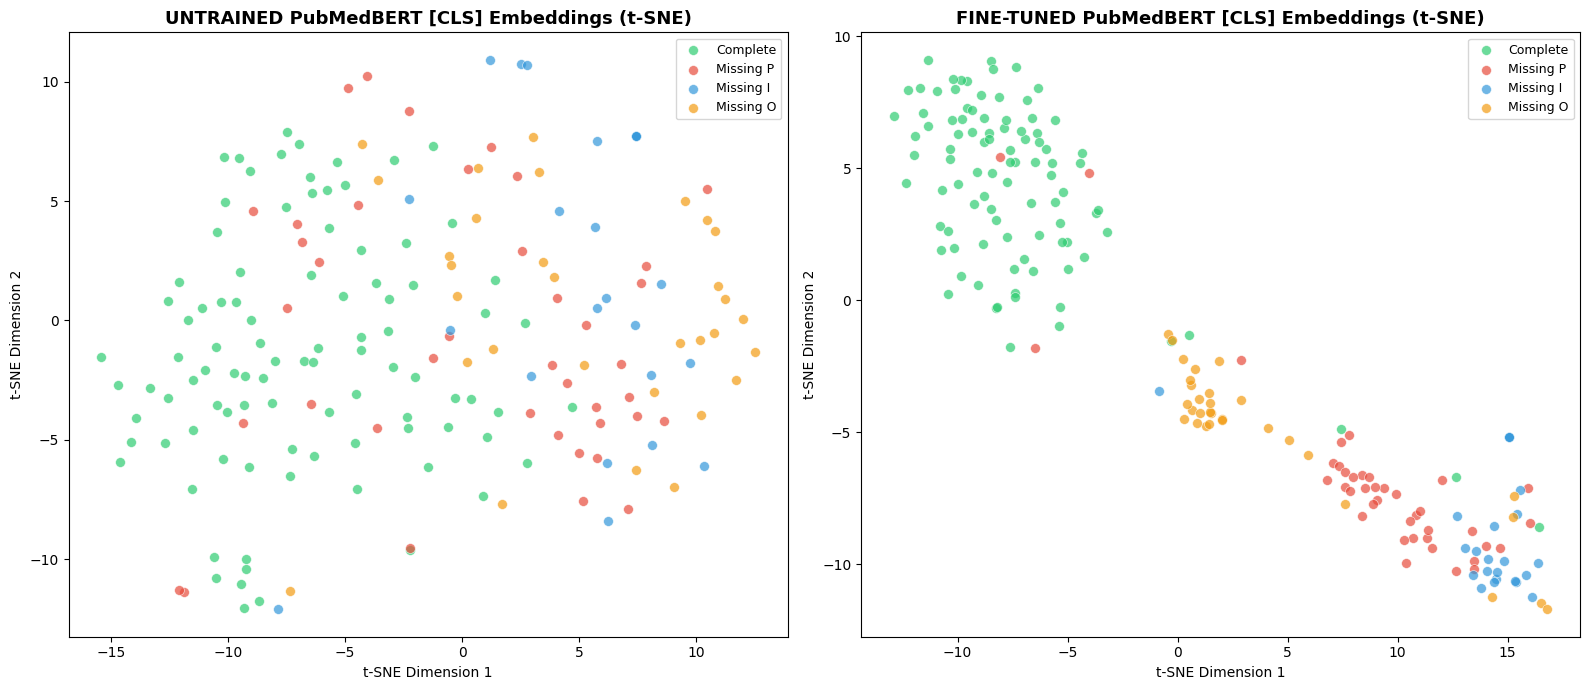

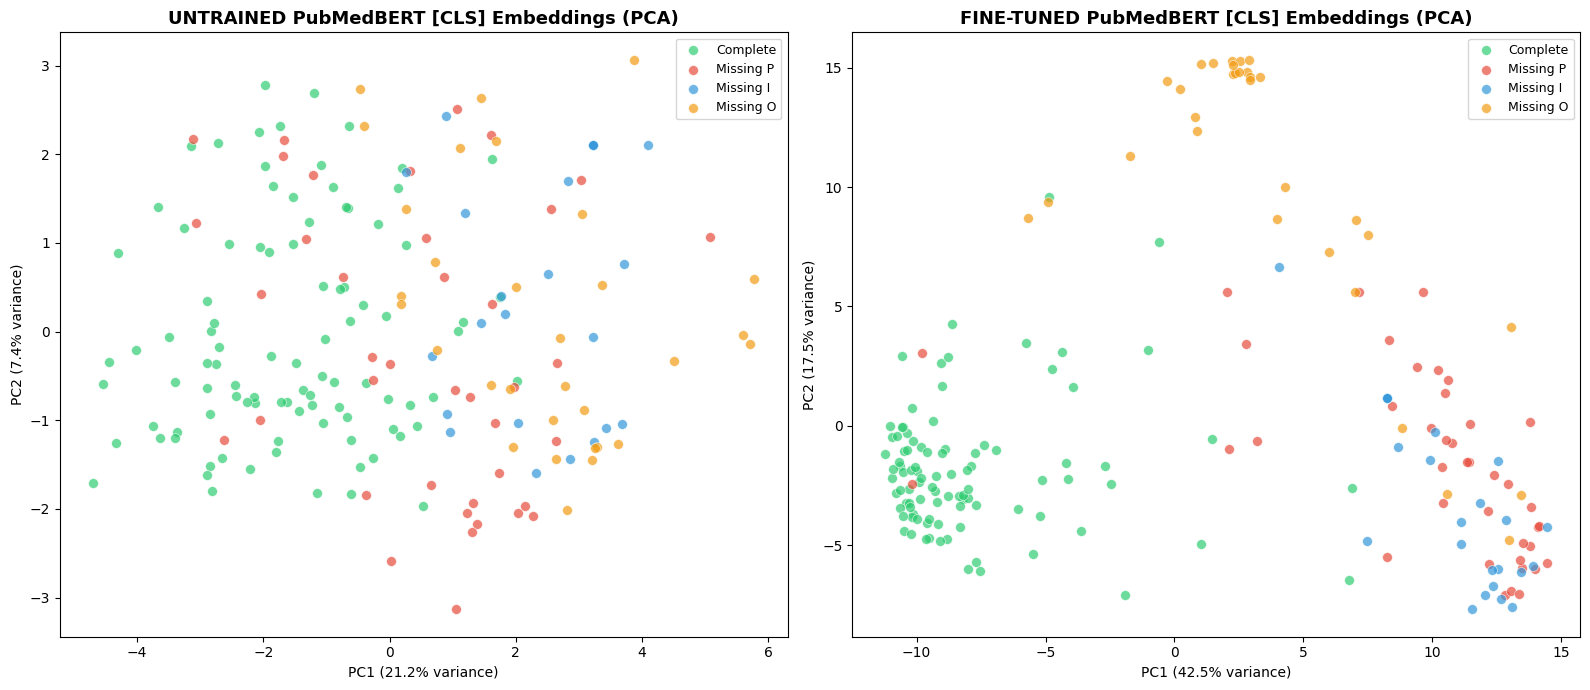

Saved: pubmedbert_tsne_before_after.png, pubmedbert_pca_before_after.png


In [7]:
print("Extracting [CLS] embeddings from FINE-TUNED PubMedBERT...")
finetuned_embeddings, _ = extract_cls_embeddings(model, test_dataloader, device)
print(f"  Shape: {finetuned_embeddings.shape}")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
untrained_tsne = tsne.fit_transform(untrained_embeddings)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
finetuned_tsne = tsne.fit_transform(finetuned_embeddings)

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for class_id in range(4):
    mask = test_labels == class_id
    axes[0].scatter(untrained_tsne[mask, 0], untrained_tsne[mask, 1],
                    c=colors[class_id], label=LABEL_NAMES[class_id], alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
    axes[1].scatter(finetuned_tsne[mask, 0], finetuned_tsne[mask, 1],
                    c=colors[class_id], label=LABEL_NAMES[class_id], alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

axes[0].set_title("UNTRAINED PubMedBERT [CLS] Embeddings (t-SNE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1"); axes[0].set_ylabel("t-SNE Dimension 2"); axes[0].legend(fontsize=9)
axes[1].set_title("FINE-TUNED PubMedBERT [CLS] Embeddings (t-SNE)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1"); axes[1].set_ylabel("t-SNE Dimension 2"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("pubmedbert_tsne_before_after.png", dpi=300, bbox_inches='tight')
plt.show()

# PCA
pca = PCA(n_components=2, random_state=42)
untrained_pca = pca.fit_transform(untrained_embeddings)
untrained_var = pca.explained_variance_ratio_

pca = PCA(n_components=2, random_state=42)
finetuned_pca = pca.fit_transform(finetuned_embeddings)
finetuned_var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for class_id in range(4):
    mask = test_labels == class_id
    axes[0].scatter(untrained_pca[mask, 0], untrained_pca[mask, 1],
                    c=colors[class_id], label=LABEL_NAMES[class_id], alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
    axes[1].scatter(finetuned_pca[mask, 0], finetuned_pca[mask, 1],
                    c=colors[class_id], label=LABEL_NAMES[class_id], alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

axes[0].set_title("UNTRAINED PubMedBERT [CLS] Embeddings (PCA)", fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({untrained_var[0]*100:.1f}% variance)"); axes[0].set_ylabel(f"PC2 ({untrained_var[1]*100:.1f}% variance)"); axes[0].legend(fontsize=9)
axes[1].set_title("FINE-TUNED PubMedBERT [CLS] Embeddings (PCA)", fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({finetuned_var[0]*100:.1f}% variance)"); axes[1].set_ylabel(f"PC2 ({finetuned_var[1]*100:.1f}% variance)"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("pubmedbert_pca_before_after.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: pubmedbert_tsne_before_after.png, pubmedbert_pca_before_after.png")


In [8]:
print("=" * 65)
print("FULL MODEL COMPARISON: BioBERT vs PubMedBERT")
print("=" * 65)
print(f"{'Model':<40} {'Accuracy':>10}")
print("-" * 52)
print(f"{'Random Chance (theoretical)':<40} {'25.00%':>10}")
print(f"{'Untrained BioBERT (Task 1 result)':<40} {'12.17%':>10}")
print(f"{'Untrained PubMedBERT':<40} {f'{untrained_accuracy*100:.2f}%':>10}")
print(f"{'Fine-Tuned BioBERT (Task 1 result)':<40} {'82.54%':>10}")
print(f"{'Fine-Tuned PubMedBERT':<40} {f'{finetuned_accuracy*100:.2f}%':>10}")
print("-" * 52)


FULL MODEL COMPARISON: BioBERT vs PubMedBERT
Model                                      Accuracy
----------------------------------------------------
Random Chance (theoretical)                  25.00%
Untrained BioBERT (Task 1 result)            12.17%
Untrained PubMedBERT                         47.09%
Fine-Tuned BioBERT (Task 1 result)           82.54%
Fine-Tuned PubMedBERT                        85.19%
----------------------------------------------------


In [9]:
import os

output_dir = './saved_pubmedbert_pico_model/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving PubMedBERT model and tokenizer to {output_dir}...")

model.config.id2label = {0: "Complete", 1: "Missing P", 2: "Missing I", 3: "Missing O"}
model.config.label2id = {"Complete": 0, "Missing P": 1, "Missing I": 2, "Missing O": 3}

model_to_save = model.module if hasattr(model, 'module') else model
model_to_save.save_pretrained(output_dir)
pubmedbert_tokenizer.save_pretrained(output_dir)
print("Save complete.")


Saving PubMedBERT model and tokenizer to ./saved_pubmedbert_pico_model/...
Save complete.
